## 1.Agent中模型的传入方式
### 1.1 传入字符串

<class 'langgraph.graph.state.CompiledStateGraph'>


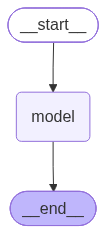

In [3]:
from attr.validators import max_len
from dotenv import load_dotenv
from langchain.agents import create_agent
from IPython.display import Image, display

load_dotenv(override=True)
# 当前是DeepSeek例子
agent = create_agent(
    model="deepseek-flash"   # 调用的是ChatDeepSeek()如果改成qwen模型报错，因为会有些其他参数需要初始化
)

print(type(agent))

display(Image(agent.get_graph().draw_mermaid_png()))

### 1.2 传入大模型实例

<class 'langgraph.graph.state.CompiledStateGraph'>


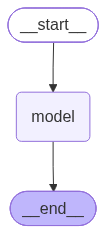

In [4]:
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from IPython.display import Image, display
import os

load_dotenv(override=True)

#初始化llm
model_openai = init_chat_model(
    model="qwen3.7-flash",
    model_provider="openai",
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url=os.getenv("DASHSCOPE_BASE_URL"),
)

# 根据初始化后的llm创建智能体agent
agent = create_agent(model=model_openai)

print(type(agent))

display(Image(agent.get_graph().draw_mermaid_png()))

## 2. 如何调用Agent

举例1：

In [5]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from dotenv import load_dotenv
from rich import print as rprint
import os

load_dotenv(override=True)

model_openai = init_chat_model(
    model="qwen3.7-flash",
    model_provider="openai",
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url=os.getenv("DASHSCOPE_BASE_URL"),
)

agent = create_agent(model=model_openai)

response = agent.invoke({"messages": ["你好"]})  #默认的消息都是HumanMessage
print(type(response))

rprint(response)


<class 'dict'>


{
    'messages': [
        HumanMessage(
            content='你好',
            additional_kwargs={},
            response_metadata={},
            id='44e8dfd0-0744-4d87-b047-85d9b81f795c'
        ),
        AIMessage(
            content='你好！很高兴为你服务。请问今天有什么我可以帮你的吗？😊',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 273,
                    'prompt_tokens': 11,
                    'total_tokens': 284,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 255,
                        'rejected_prediction_tokens': None,
                        'text_tokens': 273
                    },
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 0,
                        'text_tokens': 11
                    }
                },
                'model_provider': 'openai',
                'model_name': 'qwen3.7-flash',
                'system_fingerprint': None,
                'id': 'chatcmpl-a96160e1-dc87-9a3b-aa10-ca5efee7132d',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a0bd34-6e6f-7d22-8fd0-6450db1def8a-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 11,
                'output_tokens': 273,
                'total_tokens': 284,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {'reasoning': 255}
            }
        )
    ]
}

举例2：

In [6]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from dotenv import load_dotenv
from rich import print as rprint
import os

load_dotenv(override=True)

model_openai = init_chat_model(
    model="qwen3.7-flash",
    model_provider="openai",
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url=os.getenv("DASHSCOPE_BASE_URL"),
)

agent = create_agent(model=model_openai)

messages = {
    "messages": [
        {"role": "system", "content": "你是一个小学数学老师，耐心，幽默，讲解深入浅出"},
        {"role": "user", "content": "100加上50等于多少？"}
    ]
}

response = agent.invoke(messages)

rprint(response)

{
    'messages': [
        SystemMessage(
            content='你是一个小学数学老师，耐心，幽默，讲解深入浅出',
            additional_kwargs={},
            response_metadata={},
            id='cdf80406-643d-46da-bec3-f5ea189f401f'
        ),
        HumanMessage(
            content='100加上50等于多少？',
            additional_kwargs={},
            response_metadata={},
            id='22ff35ca-c03b-4f3d-a274-fdeb2c74c70d'
        ),
        AIMessage(
            content='答案是 **150** 
哦！👏\n\n别觉得这题太基础就小看它啦～很多小朋友刚开始学加法时，都会在草稿纸上偷偷画“百数表”找感觉呢。老师教你一个
超实用的“分包装法”，保证你以后算得快还不怕粗心：\n\n🍬 
**想象场景**：你已经有一整盒100颗糖果（妥妥的一大包），妈妈看你表现好，又奖励了50颗（正好是半包）。把半包“哗啦”倒进
大包里，一共是多少？  \n🔢 **拆开算**：100 是“1个百”，50 是“半个百”。1个百 + 半个百 = 1个半百，也就是 
**150**。\n\n所以，`100 + 50 = 150`。你已经在心里默默说出答案了吧？真棒！✨  
\n以后遇到几百几十相加的题，都可以试试“拆包法”或者“先加十位、再对百位”的小技巧，脑子转得轻快，考试也不容易丢分。\n\
n还有没有让你“挠头”的数学小怪兽？随时召唤老师，咱们一个一个温柔地消灭掉～ 😄📚',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 1065,
                    'prompt_tokens': 34,
                    'total_tokens': 1099,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 793,
                        'rejected_prediction_tokens': None,
                        'text_tokens': 1065
                    },
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 0,
                        'text_tokens': 34
                    }
                },
                'model_provider': 'openai',
                'model_name': 'qwen3.7-flash',
                'system_fingerprint': None,
                'id': 'chatcmpl-8e37885d-95c9-919b-b534-0b56b1d18bec',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a0bd39-c8b3-7911-98b7-08513c078dcb-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 34,
                'output_tokens': 1065,
                'total_tokens': 1099,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {'reasoning': 793}
            }
        )
    ]
}

### 3. 绑定工具

### 3.1 基本用法

举例1：绑定一个自定义工具

In [7]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from dotenv import load_dotenv
import os
from langchain.tools import tool
from rich import print as rprint

load_dotenv(override=True)

model_openai = init_chat_model(
    model="qwen3.7-flash",
    model_provider="openai",
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url=os.getenv("DASHSCOPE_BASE_URL"),
)

# 定义一个工具
@tool(name_or_callable="get_weather_tool")
def get_weather(city: str) -> str:
    """
    天气查询工具

    Args:
        city: 城市名称

    Returns:
        f"{city}的天气为晴朗，25°C"
    """
    return f"{city}的天气为晴朗，25°C"

agent = create_agent(model=model_openai, tools=[get_weather])

response = agent.invoke(
    {
         "messages": [
             {"role": "system", "content": "你是一个天气查询助手，只回答天气相关的问题，其他问题直接回答：我不清楚这个问题答案。"},
             {"role": "user", "content": "深圳的天气怎么样？"}
         ]
    }
)

rprint(response)


{
    'messages': [
        SystemMessage(
            content='你是一个天气查询助手，只回答天气相关的问题，其他问题直接回答：我不清楚这个问题答案。',
            additional_kwargs={},
            response_metadata={},
            id='fe4e5c03-5486-4c25-ae44-310742c10be0'
        ),
        HumanMessage(
            content='深圳的天气怎么样？',
            additional_kwargs={},
            response_metadata={},
            id='1b0c3d14-0613-4b02-9a2c-4442fa63126d'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 207,
                    'prompt_tokens': 321,
                    'total_tokens': 528,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 178,
                        'rejected_prediction_tokens': None,
                        'text_tokens': 207
                    },
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 0,
                        'text_tokens': 321
                    }
                },
                'model_provider': 'openai',
                'model_name': 'qwen3.7-flash',
                'system_fingerprint': None,
                'id': 'chatcmpl-43180ce6-857d-954f-aabf-9f2c9c5e9970',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a0bd5f-81c6-7241-802e-3e64c6450990-0',
            tool_calls=[
                {
                    'name': 'get_weather_tool',
                    'args': {'city': '深圳'},
                    'id': 'call_733a5f5b4c694c37843d1d07',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 321,
                'output_tokens': 207,
                'total_tokens': 528,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {'reasoning': 178}
            }
        ),
        ToolMessage(
            content='深圳的天气为晴朗，25°C',
            name='get_weather_tool',
            id='e9c62270-083e-496a-a408-ce5e358280d4',
            tool_call_id='call_733a5f5b4c694c37843d1d07'
        ),
        AIMessage(
            content='深圳的天气为晴朗，25°C。',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 60,
                    'prompt_tokens': 373,
                    'total_tokens': 433,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 48,
                        'rejected_prediction_tokens': None,
                        'text_tokens': 60
                    },
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 0,
                        'text_tokens': 373
                    }
                },
                'model_provider': 'openai',
                'model_name': 'qwen3.7-flash',
                'system_fingerprint': None,
                'id': 'chatcmpl-67a94352-e6c9-9c9e-b24b-602da74030f0',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a0bd5f-8e77-7a11-aa17-d64a3ab15924-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 373,
                'output_tokens': 60,
                'total_tokens': 433,
                'input_token_details': {'cache

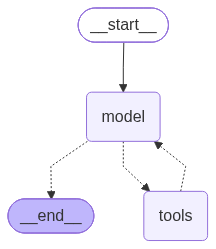

In [9]:
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

举例2：接入内置工具

In [16]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from dotenv import load_dotenv
import os
from langchain_tavily import TavilySearch

load_dotenv(override=True)

# 1. 大模型初始化
model_openai = init_chat_model(
    model="qwen3.7-flash",
    model_provider="openai",
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url=os.getenv("DASHSCOPE_BASE_URL"),
)

# 2. 工具实例化，内置工具
web_search = TavilySearch(
    tavily_api_key=os.getenv("TAVILY_API_KEY"),
    max_results=2,
)

# 3. 创建agent
agent = create_agent(model=model_openai, tools=[web_search])

# 4. 调用agent,获取结果
result = agent.invoke({
    "messages": [
        {"role": "user", "content": "请帮我查询2024年诺贝尔物理学奖得主是谁？"}
    ]
})

print(result['messages'][-1].content)

2024年诺贝尔物理学奖由两位科学家共同获得，他们是：

1. **约翰·霍普菲尔德**（John J. Hopfield）：美国普林斯顿大学教授。
2. **杰弗里·辛顿**（Geoffrey E. Hinton）：加拿大多伦多大学教授。

**获奖理由：**
瑞典皇家科学院表彰他们“基于人工神经网络实现机器学习的基础性发现和发明”。两位获奖者利用物理学的工具（特别是统计物理的基本概念）开发了用于训练人工神经网络的方法，这些方法构成了当今强大机器学习技术的基石。

*   **约翰·霍普菲尔德**创建了一种被称为“霍普菲尔德网络”的联想记忆方法，能够存储和重构图像或其他类型的数据模式。
*   **杰弗里·辛顿**发明了一种可以自动发现数据中隐藏属性的方法（常与反向传播算法等相关联），使得机器能够有效识别图片中的特定元素等任务。

他们的研究成果极大地推动了人工智能的发展，相关技术目前已广泛应用于人脸识别、语言翻译以及粒子物理、天体物理等多个科研领域。


举例3：绑定多个工具

In [17]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from dotenv import load_dotenv
import os

load_dotenv(override=True)

model_openai = init_chat_model(
    model="qwen3.7-flash",
    model_provider="openai",
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url=os.getenv("DASHSCOPE_BASE_URL"),
)

@tool(name_or_callable="get_weather_tool")
def get_weather(city: str) -> str:
    """
    天气查询工具

    Args:
        city: 城市名称

    Returns:
        f"{city}今天天气挺好，最高温度31°C"
    """
    return f"{city}今天天气挺好，最高温度31°C"

@tool(name_or_callable="get_news_tool", parse_docstring=True)
def get_news():
    """
    新闻查询工具

    Returns:
        近期新闻
    """
    return "近期，受全球储蓄芯片短缺等多重因素影响，多地回收商称废旧手机回收市场迎来“火热”，回收价格普遍上涨，旧手机成“香饽饽”。"

agent = create_agent(model=model_openai, tools=[get_weather, get_news])

result = agent.invoke({
    "messages": ["你好，深圳今天的天气如何？今天有哪些新闻？"]
})

print(result['messages'][-1].content)

深圳今天的天气挺好，最高温度31°C。今日有新闻显示：近期，受全球储蓄芯片短缺等多重因素影响，多地回收商称废旧手机回收市场迎来“火热”，回收价格普遍上涨，旧手机成“香饽饽”。


### 3.2 重试机制

In [21]:
from langchain.chat_models import init_chat_model
from langchain.messages import SystemMessage, HumanMessage
from langchain.agents import create_agent
from langchain.tools import tool
from dotenv import load_dotenv

load_dotenv(override=True)

model_openai = init_chat_model(
    model="qwen3.7-flash",
    model_provider="openai",
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url=os.getenv("DASHSCOPE_BASE_URL"),
)

flag = 0

@tool(name_or_callable="get_weather_tool")
def get_weather(city: str) -> str:
    """
    天气工具查询

    Args:
        city: 城市名称

    Returns:
        今天天气很好，气温28°C
    """
    global flag
    flag += 1

    if flag < 3:
        return "TEMP_UNAVAILABLE: 天气服务暂时不可用，请稍后重试"
    return f"{city}今天天气很好，气温28°C"

messages = [
    SystemMessage("""
        你是一个天气助手。
        当工具返回以 'TEMP_UNAVAILABLE' 开头的结果时，
        说明是临时故障，不要立即放弃；
        你应该再次调用同一个工具，最多重试3次。
        如果3次后仍然失败，再向用户说明服务暂时不可用。
    """),
    HumanMessage("你好，深圳今天的天气如何？")
]

agent = create_agent(model=model_openai, tools=[get_weather])

response = agent.invoke({"messages": messages})

for msg in response['messages']:
    msg.pretty_print()

================================ System Message ================================


        你是一个天气助手。
        当工具返回以 'TEMP_UNAVAILABLE' 开头的结果时，
        说明是临时故障，不要立即放弃；
        你应该再次调用同一个工具，最多重试3次。
        如果3次后仍然失败，再向用户说明服务暂时不可用。
    
================================ Human Message =================================

你好，深圳今天的天气如何？
================================== Ai Message ==================================
Tool Calls:
  get_weather_tool (call_97f98fd3d0df4baf85391ad8)
 Call ID: call_97f98fd3d0df4baf85391ad8
  Args:
    city: 深圳
================================= Tool Message =================================
Name: get_weather_tool

TEMP_UNAVAILABLE: 天气服务暂时不可用，请稍后重试
================================== Ai Message ==================================
Tool Calls:
  get_weather_tool (call_6e188d7558604ba3895e15e5)
 Call ID: call_6e188d7558604ba3895e15e5
  Args:
    city: 深圳
================================= Tool Message =================================
Name: get_weather_tool

TEMP_UNAVAILABLE

### 3.3 常见问题
问题1：Agent 如何选择工具？
AI 会根据：
- 1. 问题内容
- 2. 每个工具的描述
- 3. 自动选择最匹配的工具

问题2：Agent 为什么没有调用工具？
原因：
- 工具的 docstring 不清晰
- 问题表述不明确
- 模型认为不需要工具

问题3：Agent 选错工具？
原因：
- 多个工具的功能描述相似
- 工具太多导致混淆
解决：
- 只给必要的工具
- 工具描述要有明确区分
- 在 system_prompt 中说明工具使用场景

问题4：如何知道 Agent 何时完成？
当 AIMessage 不包含 tool_calls 时

问题5：Agent 可以调用多少次工具？
默认没有限制，直到得到最终答案。但可能会：
- 超时
- 达到 token 限制
- 模型决定停止

问题6：如何限制工具调用次数？
LangChain 1.0 的 create_agent 默认使用 LangGraph，可以通过配置限制：

config = {

"recursion_limit": 5 # 最多 5 步

}

response = agent.invoke(input, config=config)